In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [22]:
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv(r"C:\Users\avanindra Bose\OneDrive\Desktop\Real State Project\Cleaned Datasets\gurgaon_properties_outliers_treated.csv")

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.isnull().sum()

property_type               0
society                     1
sector                      0
price                       0
price_per_square_feet       0
area                        0
areaWithType                0
bedRoom                     0
bathroom                    0
balcony                     0
floorNum                   17
facing                   1010
agePossession               0
super_built_up_area      1680
built_up_area            1967
carpet_area              1714
study room                  0
servant room                0
store room                  0
pooja room                  0
others                      0
furnishing_type             0
luxury_score                0
area_room_ratio             0
dtype: int64

# Built Up Area

<Axes: xlabel='built_up_area', ylabel='super_built_up_area'>

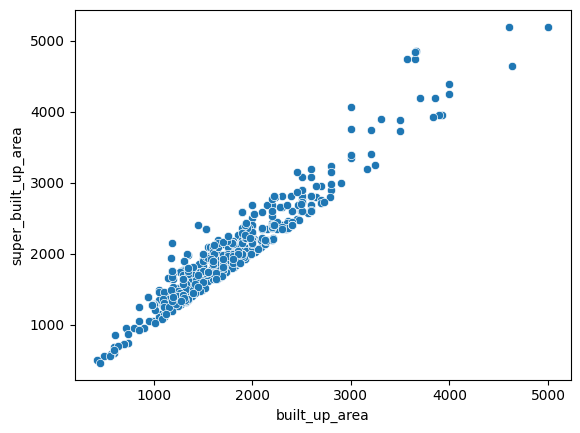

In [8]:
sns.scatterplot(data=df, y='super_built_up_area', x='built_up_area')

<Axes: xlabel='built_up_area', ylabel='carpet_area'>

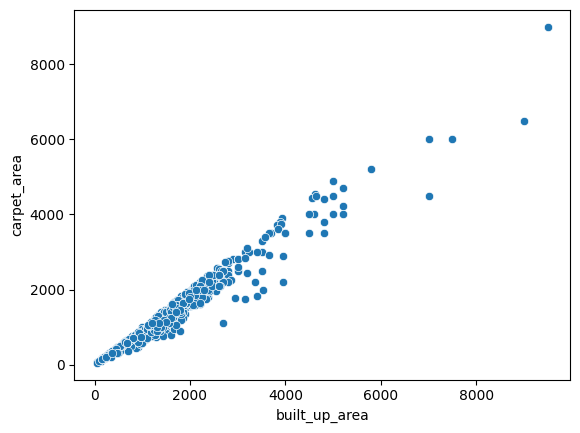

In [9]:
sns.scatterplot(data=df, y='carpet_area', x='built_up_area')

C:\Users\avanindra Bose\AppData\Local\Temp\ipykernel_72348\1547516413.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['built_up_area'] , kde = True)


<Axes: xlabel='built_up_area', ylabel='Density'>

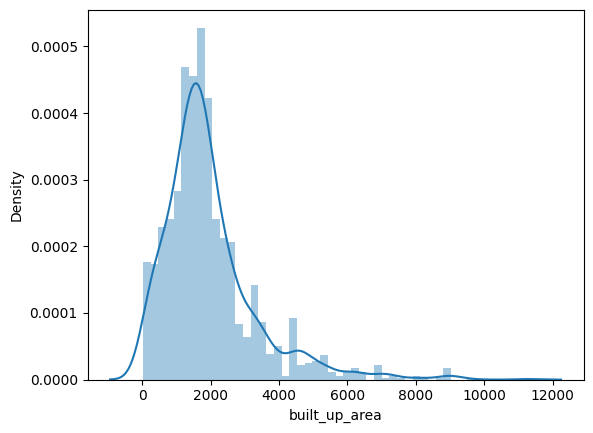

In [10]:
sns.distplot(df['built_up_area'] , kde = True)

In [11]:
((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull())).sum()

np.int64(0)

In [12]:
all_present_df = df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))]

In [13]:
all_present_df.sample(5)

,property_type,society,sector,price,price_per_square_feet,area,areaWithType,bedRoom,bathroom,balcony,...,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
1188,flat,ss,sector 85,1.98,8222.0,2408.0,Super Built up area 2408(223.71 sq.m.)Built Up...,3,4,3,...,2300.0,2200.00,0,0,0,0,0,1,42,802.666667
2777,flat,m3m skywalk,sector 74,1.52,13342.0,1139.0,Super Built up area 1400(130.06 sq.m.)Built Up...,2,2,3,...,1250.0,1139.20,0,0,1,0,0,1,174,569.500000
198,flat,emaar gurgaon greens,sector 102,1.40,8484.0,1650.0,Super Built up area 1650(153.29 sq.m.)Built Up...,3,3,3,...,1300.0,1022.58,0,1,0,0,0,1,46,550.000000
2284,flat,tulip white,sector 69,0.90,6000.0,1500.0,Super Built up area 1500(139.35 sq.m.)Built Up...,3,2,3+,...,1326.0,1050.00,0,0,0,0,0,0,149,500.000000
3186,flat,paras dews,sector 106,0.88,6353.0,1385.0,Super Built up area 1385(128.67 sq.m.)Built Up...,2,2,3+,...,940.0,845.00,0,0,0,0,0,1,49,692.500000


In [17]:
super_to_built_up_ratio = (all_present_df['super_built_up_area']/all_present_df['built_up_area']).median()

In [18]:
carpet_to_built_up_ratio = (all_present_df['carpet_area']/all_present_df['built_up_area']).median()

In [19]:
print(super_to_built_up_ratio, carpet_to_built_up_ratio)

1.105263157894737 0.9


In [20]:
sbc_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [23]:
sbc_df.sample(5)

,property_type,society,sector,price,price_per_square_feet,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
2360,flat,m3m sierra 68,sector 68,1.25,10245.0,1220.0,Super Built up area 1220(113.34 sq.m.)Carpet a...,2,2,3,4.0,NaN,New Property,1220.0,NaN,694.00,0,0,0,0,0,1,44,610.00
584,flat,conscient elevate,sector 59,6.75,19882.0,3395.0,Super Built up area 3395(315.41 sq.m.)Carpet a...,4,4,2,10.0,NaN,New Property,3395.0,NaN,1855.00,0,1,0,0,0,1,31,848.75
846,flat,pivotal devaan apartments,sector 84,0.39,6500.0,600.0,Super Built up area 600(55.74 sq.m.)Carpet are...,2,2,0,5.0,North,Undefined,600.0,NaN,500.00,0,0,0,0,0,1,0,300.00
2543,flat,hero homes,sector 104,1.20,17548.0,684.0,Super Built up area 1099(102.1 sq.m.)Carpet ar...,2,2,2,22.0,NaN,Under Construction,1099.0,NaN,683.83,0,0,0,0,0,1,30,342.00
2116,flat,indiabulls centrum park,sector 103,2.36,9182.0,2570.0,Super Built up area 2875(267.1 sq.m.)Carpet ar...,4,6,3+,8.0,East,Relatively New,2875.0,NaN,2570.00,0,1,0,0,0,0,159,642.50


In [25]:
sbc_df['built_up_area'].fillna(round(((sbc_df['super_built_up_area']/1.105) + (sbc_df['carpet_area']/0.9))/2),inplace=True)

C:\Users\avanindra Bose\AppData\Local\Temp\ipykernel_72348\1215074969.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sbc_df['built_up_area'].fillna(round(((sbc_df['super_built_up_area']/1.105) + (sbc_df['carpet_area']/0.9))/2),inplace=True)
C:\Users\avanindra Bose\AppData\Local\Temp\ipykernel_72348\1215074969.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-

In [26]:
df.update(sbc_df)

In [27]:
df.isnull().sum()

property_type               0
society                     1
sector                      0
price                       0
price_per_square_feet       0
area                        0
areaWithType                0
bedRoom                     0
bathroom                    0
balcony                     0
floorNum                   17
facing                   1010
agePossession               0
super_built_up_area      1680
built_up_area            1546
carpet_area              1714
study room                  0
servant room                0
store room                  0
pooja room                  0
others                      0
furnishing_type             0
luxury_score                0
area_room_ratio             0
dtype: int64

C:\Users\avanindra Bose\AppData\Local\Temp\ipykernel_72348\232865866.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['built_up_area'], kde=True)


<Axes: xlabel='built_up_area', ylabel='Density'>

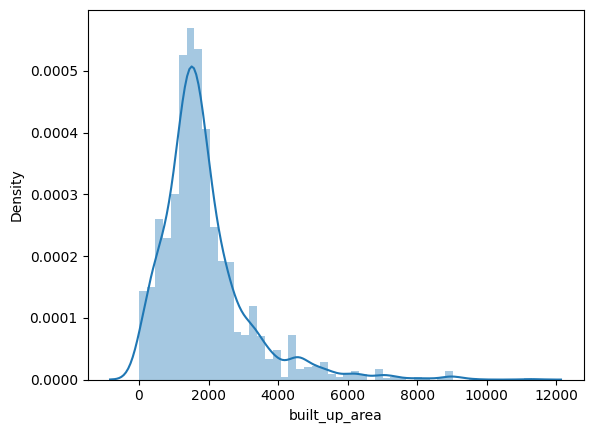

In [28]:
sns.distplot(df['built_up_area'], kde=True)

In [29]:
btr = df['built_up_area']

In [30]:
# sb present c is null built up null
sb_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull())]

In [32]:
sb_df.shape

(874, 24)

In [33]:
sb_df.sample(5)

,property_type,society,sector,price,price_per_square_feet,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
3013,flat,kashish manor one,sector 111,1.65,7097.0,2325.0,Super Built up area 2325(216 sq.m.),3,4,3+,14.0,NaN,Under Construction,2325.0,NaN,NaN,0,1,0,0,1,1,8,775.000000
351,flat,godrej,sector 79,1.33,8531.0,1559.0,Super Built up area 1559(144.84 sq.m.),2,2,3,6.0,North-West,Relatively New,1559.0,NaN,NaN,1,0,0,0,0,1,158,779.500000
337,flat,sidhartha ncr greens,sector 95,0.60,5576.0,1076.0,Super Built up area 1076(99.96 sq.m.),2,2,2,14.0,NaN,Relatively New,1076.0,NaN,NaN,1,0,0,0,0,1,31,538.000000
2999,flat,conscient heritage max,sector 102,2.15,10004.0,2149.0,Super Built up area 2149(199.65 sq.m.),3,4,3+,18.0,South,Relatively New,2149.0,NaN,NaN,1,1,0,0,0,0,134,716.333333
688,flat,godrej aria,sector 79,1.10,11482.0,958.0,Super Built up area 89,2,2,3,9.0,NaN,New Property,89.0,NaN,NaN,0,0,0,0,0,1,62,479.000000


In [37]:
sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.105), inplace=True)

C:\Users\avanindra Bose\AppData\Local\Temp\ipykernel_72348\1215299602.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.105), inplace=True)
C:\Users\avanindra Bose\AppData\Local\Temp\ipykernel_72348\1215299602.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sb_df['built_u

In [38]:
df.update(sb_df)

In [39]:
df.isnull().sum()

property_type               0
society                     1
sector                      0
price                       0
price_per_square_feet       0
area                        0
areaWithType                0
bedRoom                     0
bathroom                    0
balcony                     0
floorNum                   17
facing                   1010
agePossession               0
super_built_up_area      1680
built_up_area             672
carpet_area              1714
study room                  0
servant room                0
store room                  0
pooja room                  0
others                      0
furnishing_type             0
luxury_score                0
area_room_ratio             0
dtype: int64

C:\Users\avanindra Bose\AppData\Local\Temp\ipykernel_72348\232865866.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['built_up_area'], kde=True)


<Axes: xlabel='built_up_area', ylabel='Density'>

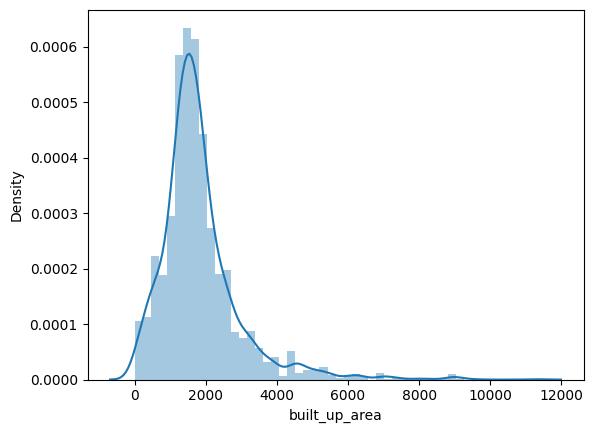

In [40]:
sns.distplot(df['built_up_area'], kde=True)

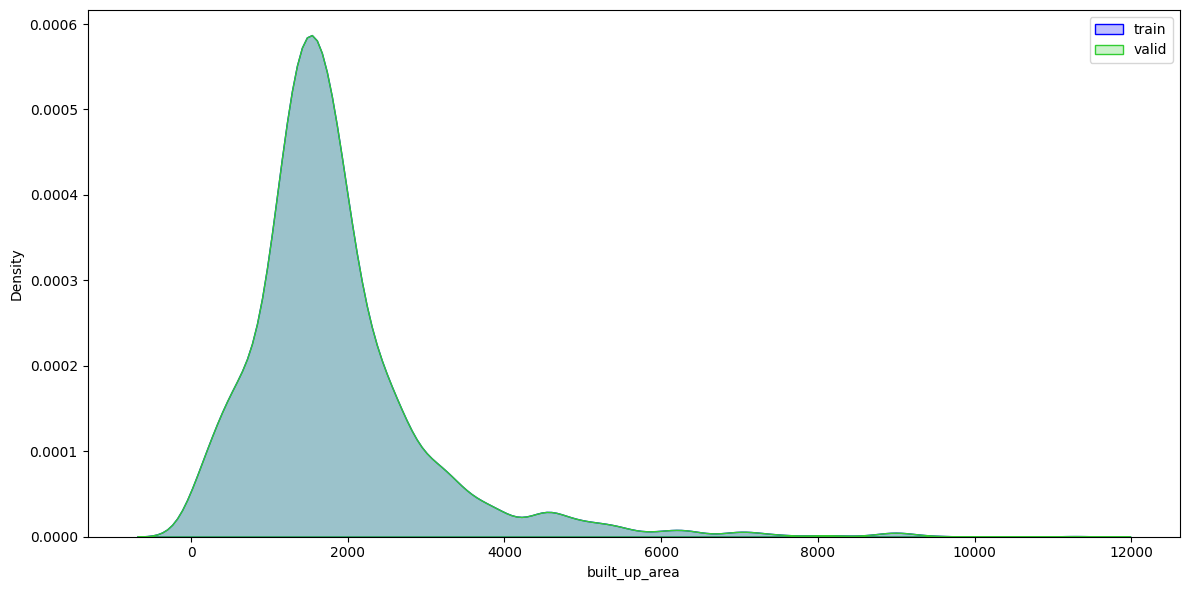

In [52]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.kdeplot(data=btr,
            color='blue', label='train', fill=True, ax=ax)
sns.kdeplot(data=df['built_up_area'],
            color='limegreen', label='valid', fill=True, ax=ax)
ax.legend()
plt.tight_layout()
plt.show()

In [53]:
c_df = df[(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [55]:
c_df.shape

(672, 24)

In [56]:
c_df.sample(5)

,property_type,society,sector,price,price_per_square_feet,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
2167,flat,ambience creacions,sector 22,6.16,20533.0,3000.0,Carpet area: 3000 (278.71 sq.m.),4,5,3+,10.0,South-East,New Property,NaN,NaN,3000.0,0,1,0,1,0,0,49,750.000000
1854,flat,raheja the vedaanta floors,sector 108,0.70,4521.0,1548.0,Carpet area: 1548 (143.81 sq.m.),2,2,3,1.0,NaN,Moderately Old,NaN,NaN,1548.0,0,0,0,0,0,0,0,774.000000
1065,flat,apartment,sector 92,0.75,4687.0,1600.0,Carpet area: 1600 (148.64 sq.m.),3,4,3,2.0,East,Moderately Old,NaN,NaN,1600.0,1,0,0,0,0,1,113,533.333333
813,flat,palam vihar extension west zone rwa,sector 2,0.20,4000.0,500.0,Carpet area: 500 (46.45 sq.m.),1,1,1,1.0,NaN,Moderately Old,NaN,NaN,500.0,0,0,0,0,1,1,0,500.000000
3099,flat,vatika city,sector 49,3.60,11920.0,3020.0,Carpet area: 3020 (280.57 sq.m.),4,5,3,7.0,NaN,Moderately Old,NaN,NaN,3020.0,0,1,0,1,0,2,15,755.000000


In [58]:
c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.9),inplace=True)

C:\Users\avanindra Bose\AppData\Local\Temp\ipykernel_72348\2136919732.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.9),inplace=True)
C:\Users\avanindra Bose\AppData\Local\Temp\ipykernel_72348\2136919732.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  c_df['built_up_area'].filln

In [59]:
df.update(c_df)

In [60]:
df.isnull().sum()

property_type               0
society                     1
sector                      0
price                       0
price_per_square_feet       0
area                        0
areaWithType                0
bedRoom                     0
bathroom                    0
balcony                     0
floorNum                   17
facing                   1010
agePossession               0
super_built_up_area      1680
built_up_area               0
carpet_area              1714
study room                  0
servant room                0
store room                  0
pooja room                  0
others                      0
furnishing_type             0
luxury_score                0
area_room_ratio             0
dtype: int64

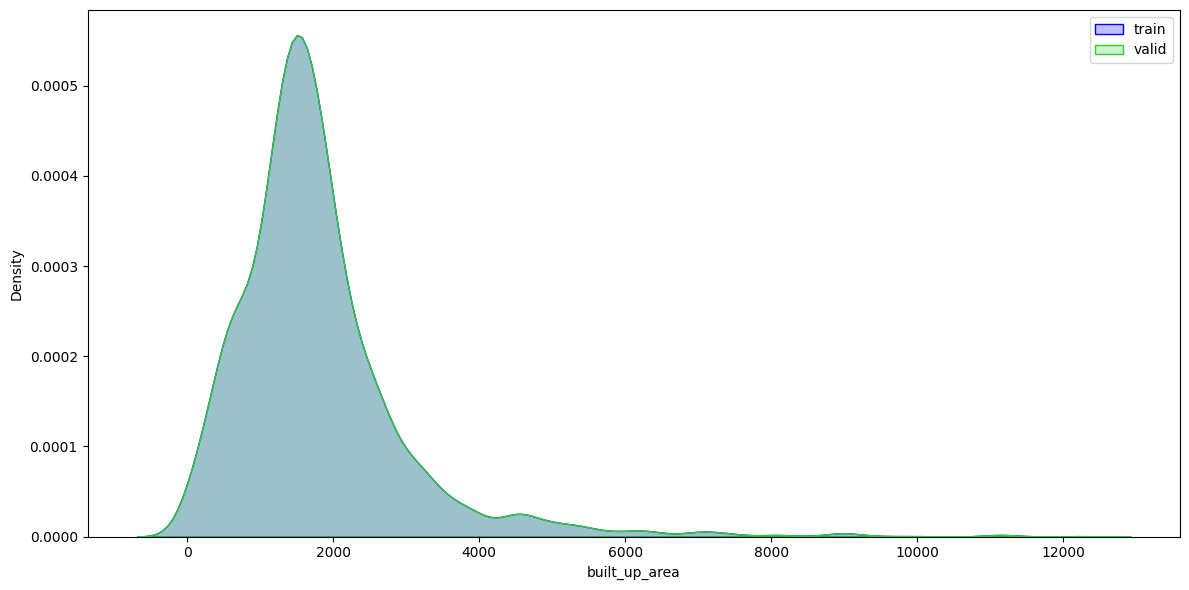

In [61]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.kdeplot(data=btr,
            color='blue', label='train', fill=True, ax=ax)
sns.kdeplot(data=df['built_up_area'],
            color='limegreen', label='valid', fill=True, ax=ax)
ax.legend()
plt.tight_layout()
plt.show()

# Built Up Area was MCAR -> Hence we dont see any changes after imputing missing values

<Axes: xlabel='built_up_area', ylabel='price'>

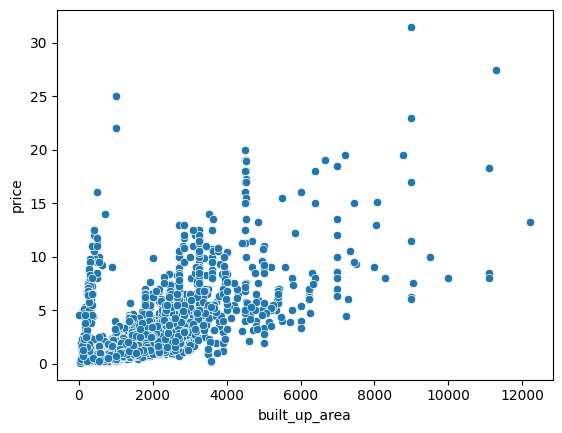

In [63]:
sns.scatterplot(x = df['built_up_area'],y = df['price'])

In [64]:
anamoly_df = df[(df['built_up_area'] < 2000) & (df['price'] > 2.5)][['price','area','built_up_area']]

In [67]:
anamoly_df.sample(5)

,price,area,built_up_area
1700,11.75,5056.0,502.0
2585,3.50,1458.0,161.0
970,5.15,3660.0,340.0
2219,3.00,1828.0,1654.0
1280,2.80,1557.0,160.0


In [68]:
anamoly_df['built_up_area'] = anamoly_df['area']

In [69]:
df.update(anamoly_df)

<Axes: xlabel='built_up_area', ylabel='price'>

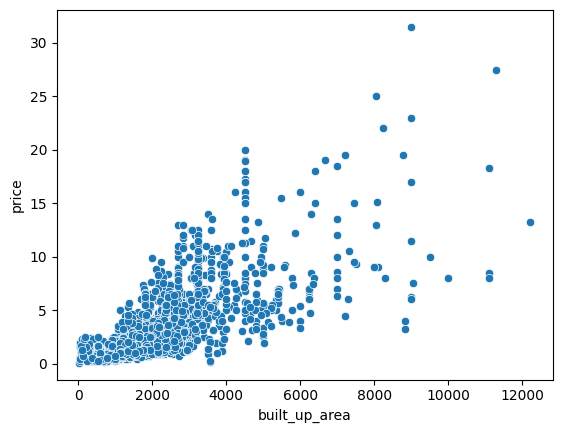

In [71]:
sns.scatterplot(x = df['built_up_area'],y = df['price'])

In [72]:
df.drop(columns=['area','areaWithType','super_built_up_area','carpet_area','area_room_ratio'],inplace=True)

In [73]:

df.head()

,property_type,society,sector,price,price_per_square_feet,bedRoom,bathroom,balcony,floorNum,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,rof aalayas,sector 102,0.45,6000.0,1,1,2,6.0,NaN,Undefined,750.0,0,0,0,0,0,1,0
1,house,huda sector-56 gurgaon,sector 56,3.60,24845.0,5,5,3+,3.0,North-East,Moderately Old,1449.0,0,0,0,0,1,1,47
2,flat,parsvnath green ville,sector 48,2.50,12820.0,4,5,3,1.0,South-East,Moderately Old,2167.0,0,0,0,0,1,0,49
3,flat,emaar gurgaon greens,sector 102,1.35,8181.0,3,3,3,5.0,North-West,Relatively New,1315.0,0,1,0,0,0,1,119
4,flat,raheja sampada,sector 92,0.65,4744.0,3,2,3,6.0,North-East,Relatively New,1240.0,0,0,0,0,0,1,49


In [74]:
df.shape

(3554, 19)

# FloorNum

In [77]:
df['floorNum'].isnull().sum()

np.int64(17)

In [79]:
df[df['floorNum'].isnull()]

,property_type,society,sector,price,price_per_square_feet,bedRoom,bathroom,balcony,floorNum,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
70,house,independent,sector 4,0.65,11111.0,4,2,2,NaN,NaN,Moderately Old,585.0,0,0,0,0,0,1,0
341,house,emaar mgf marbella,sector 66,9.00,21251.0,4,4,3+,NaN,South-West,Relatively New,5200.0,0,1,1,1,0,0,114
426,house,independent,sector 7,6.50,15046.0,3,2,3+,NaN,NaN,Old Property,4320.0,0,0,0,0,0,1,9
606,flat,NaN,sector 78,0.60,3692.0,2,2,0,NaN,NaN,Under Construction,1625.0,0,0,0,0,0,1,0
608,house,ansal sushant lok plots,sector 43,3.30,26570.0,1,1,0,NaN,NaN,Under Construction,1242.0,0,0,0,0,0,1,0
975,house,ansal sushant lok,sector 43,10.50,27911.0,4,4,2,NaN,North-East,Old Property,3762.0,0,1,0,0,0,1,59
1344,house,independent,sector 4,4.12,8889.0,2,1,3+,NaN,NaN,Moderately Old,4635.0,0,0,0,0,0,1,0
1546,house,independent,sector 2,5.60,17284.0,8,6,3+,NaN,South-West,Moderately Old,3240.0,1,1,1,1,0,1,0
1910,house,vipul tatvam villa,sector 48,8.50,26235.0,4,4,2,NaN,East,Moderately Old,3240.0,0,1,1,1,0,1,88
1919,house,independent,sector 25,13.00,45710.0,6,8,3+,NaN,NaN,Relatively New,2844.0,1,1,1,1,0,2,0


C:\Users\avanindra Bose\AppData\Local\Temp\ipykernel_72348\3937328942.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['floorNum'],kde = True)


<Axes: xlabel='floorNum', ylabel='Density'>

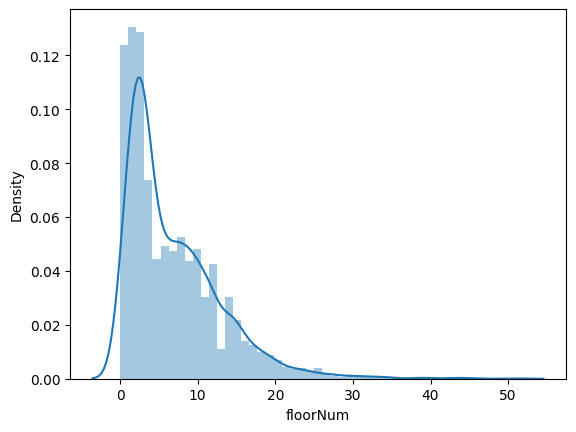

In [80]:
sns.distplot(df['floorNum'],kde = True)

In [85]:
median = df[df['property_type'] == 'house']['floorNum'].median()

In [84]:
x = df['floorNum']

In [86]:
df['floorNum'].fillna(median , inplace=True)

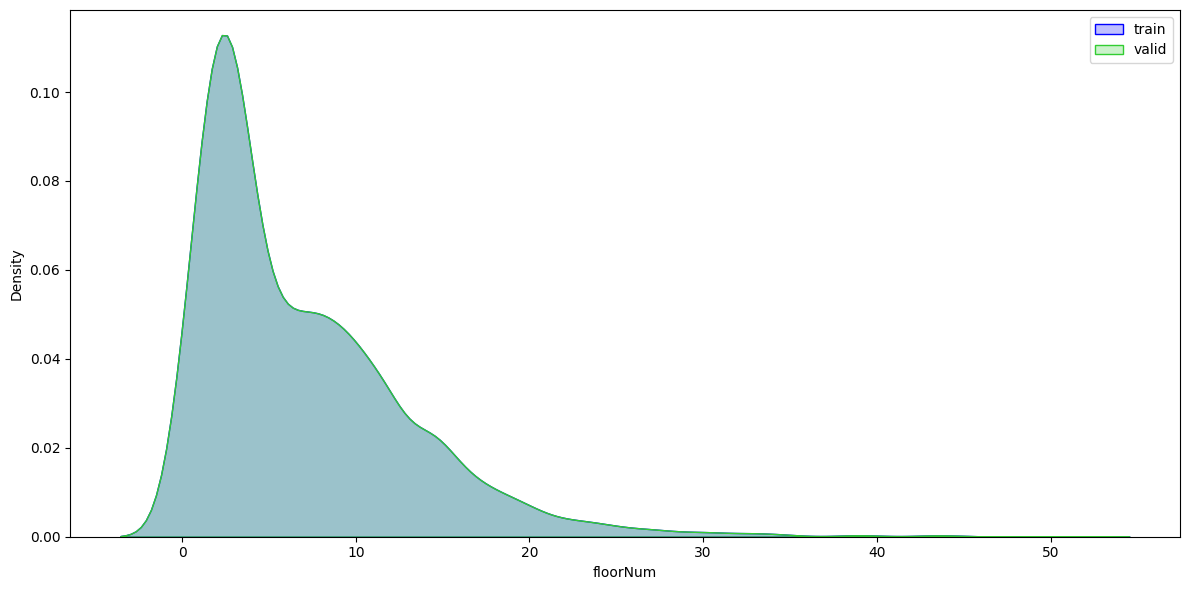

In [90]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.kdeplot(x,
            color='blue', label='train', fill=True, ax=ax)
sns.kdeplot(df['floorNum'],
            color='limegreen', label='valid', fill=True, ax=ax)
ax.legend()
plt.tight_layout()
plt.show()

# Hence Flor Num was MCAR -> Distribution doesnt change much after missing value imputation

# Facing

<Axes: ylabel='count'>

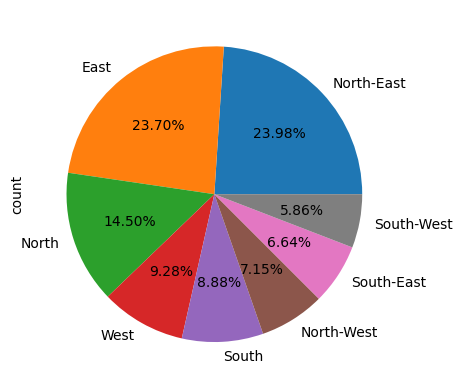

In [91]:
df['facing'].value_counts().plot(kind='pie',autopct='%0.2f%%')

In [96]:
(df['facing'].isnull().sum())/df.shape[0]

np.float64(0.28418683173888576)

In [99]:
df.drop(columns=['facing'],inplace=True)

In [101]:
df.drop(index=[606] , inplace=True)

In [102]:
df.shape

(3553, 18)

# Age Possession (Imp)

In [103]:
df['agePossession'].value_counts()

agePossession
Relatively New        1604
New Property           557
Moderately Old         545
Old Property           293
Undefined              291
Under Construction     263
Name: count, dtype: int64

In [105]:
ct = pd.crosstab(df['agePossession'] , df['property_type'])

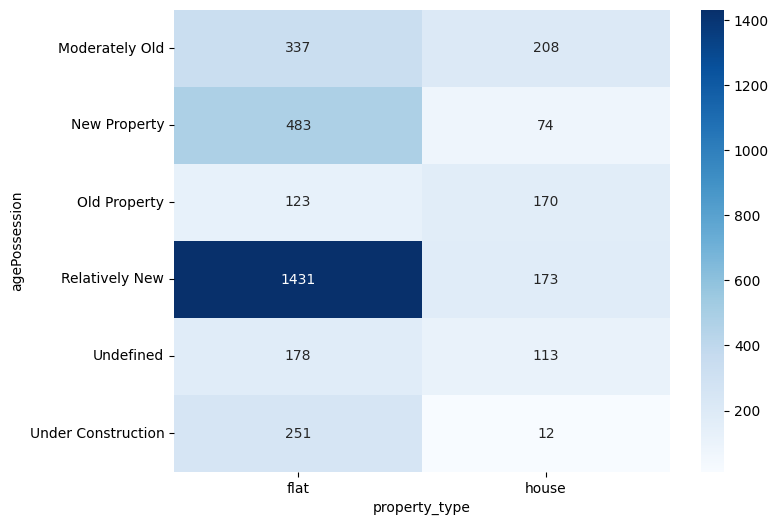

In [106]:
plt.figure(figsize=(8,6))
sns.heatmap(ct, annot=True, fmt="d", cmap="Blues")
plt.show()

In [107]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(ct)

print("Chi-square test p-value:", p)

Chi-square test p-value: 5.953497405884455e-118


In [108]:
n = ct.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape)-1)))
print("Cramér's V:", cramers_v)

Cramér's V: 0.3956444908439507


Property and Age Possession are strongly Related

In [135]:
ct2 = pd.crosstab(df['agePossession'],df['sector'])

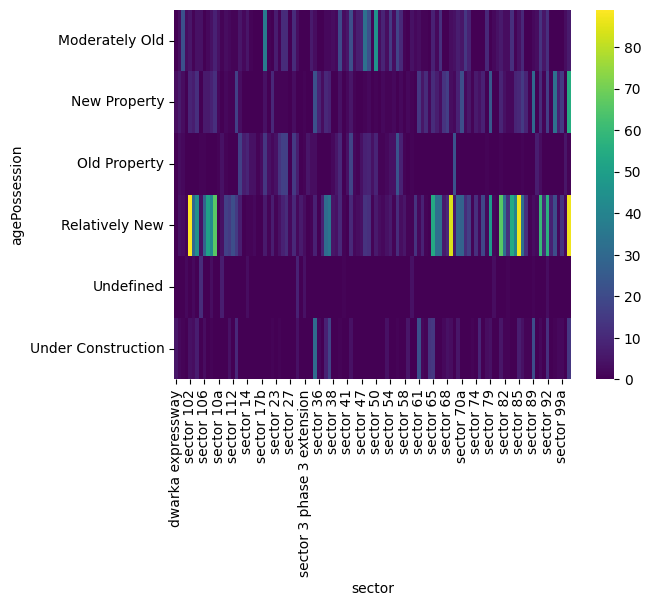

In [136]:
sns.heatmap(ct2, fmt="d", cmap="viridis")
plt.show()

In [137]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(ct2)

print("Chi-square test p-value:", p)

Chi-square test p-value: 0.0


In [138]:
n = ct.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape)-1)))
print("Cramér's V:", cramers_v)

Cramér's V: 1.175055596603236


Strong Association Between Sector and Age Possession

In [131]:
val = df['agePossession']

In [129]:
df[df['agePossession'] == 'Undefined']

,property_type,society,sector,price,price_per_square_feet,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,rof aalayas,sector 102,0.45,6000.0,1,1,2,6.0,Undefined,750.0,0,0,0,0,0,1,0
7,house,anshul,sector 6,0.85,7727.0,2,2,0,4.0,Undefined,1222.0,0,0,0,0,0,1,0
17,flat,assotech blith,sector 99,1.90,6702.0,4,4,3+,2.0,Undefined,2835.0,0,0,0,0,0,1,51
42,flat,mapsko mount ville,sector 79,1.65,9091.0,3,3,0,12.0,Undefined,1815.0,0,0,0,0,0,1,0
44,flat,south city 1 floors,sector 41,3.40,11724.0,4,4,3,0.0,Undefined,2900.0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3470,house,independent,sector 9,1.65,18333.0,2,3,0,3.0,Undefined,900.0,0,0,0,0,0,1,0
3492,house,independent,sector 38,8.00,25616.0,10,10,3+,1.0,Undefined,3123.0,0,0,0,0,0,1,0
3514,house,independent,sector 13,0.45,4808.0,1,1,0,1.0,Undefined,936.0,0,0,0,0,0,1,0
3523,flat,supertech araville,sector 79,0.90,6950.0,2,2,0,12.0,Undefined,1295.0,0,0,0,0,0,1,0


In [130]:
def mode_based_imputation(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector']) & (df['property_type'] == row['property_type'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [132]:
df['agePossession'] = df.apply(mode_based_imputation,axis=1)

In [134]:
df['agePossession'].value_counts()

agePossession
Relatively New        1717
New Property           596
Moderately Old         584
Old Property           326
Under Construction     277
Undefined               53
Name: count, dtype: int64

In [139]:
def mode_based_imputation2(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [140]:

df['agePossession'] = df.apply(mode_based_imputation2,axis=1)

In [141]:
df['agePossession'].value_counts()

agePossession
Relatively New        1726
New Property           597
Moderately Old         591
Old Property           329
Under Construction     277
Undefined               33
Name: count, dtype: int64

In [142]:
def mode_based_imputation3(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['property_type'] == row['property_type'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [143]:
df['agePossession'] = df.apply(mode_based_imputation3,axis=1)

In [144]:
df['agePossession'].value_counts()

agePossession
Relatively New        1728
Moderately Old         622
New Property           597
Old Property           329
Under Construction     277
Name: count, dtype: int64

In [147]:
val.value_counts()

agePossession
Relatively New        1604
New Property           557
Moderately Old         545
Old Property           293
Undefined              291
Under Construction     263
Name: count, dtype: int64

In [145]:
df.isnull().sum()

property_type            0
society                  0
sector                   0
price                    0
price_per_square_feet    0
bedRoom                  0
bathroom                 0
balcony                  0
floorNum                 0
agePossession            0
built_up_area            0
study room               0
servant room             0
store room               0
pooja room               0
others                   0
furnishing_type          0
luxury_score             0
dtype: int64

In [155]:
df.to_csv('gurgaon_properties_missing_value_imputation.csv',index=False)

In [156]:
df.shape

(3553, 18)